In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 
from dotenv import load_dotenv
import sys
project_root = os.path.abspath("..")
sys.path.insert(0, project_root)

In [70]:
from src.utils import set_labels

In [71]:
load_dotenv()
BASE_PATH = os.getenv("BASE_PATH")
df = pd.read_parquet(f"{BASE_PATH}/data/processed/clean_weather_training_data.parquet")

df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Albury,13.4,22.900000,0.6,NaN,NaN,W,44.0,W,WNW,...,71.0,22.0,1007.700012,1007.099976,8,7,16.900000,21.799999,No,False
1,Albury,7.4,25.100000,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,44.0,25.0,1010.599976,1007.799988,8,7,17.200001,24.299999,No,False
2,Albury,17.5,32.299999,1.0,NaN,NaN,W,41.0,ENE,NW,...,82.0,33.0,1010.799988,1006.000000,7,8,17.799999,29.700001,No,False
3,Albury,14.6,29.700001,0.2,NaN,NaN,WNW,56.0,W,W,...,55.0,23.0,1009.200012,1005.400024,8,7,20.600000,28.900000,No,False
4,Albury,7.7,26.700001,0.0,NaN,NaN,W,35.0,SSE,W,...,48.0,19.0,1013.400024,1010.099976,8,7,16.299999,25.500000,No,False


In [126]:
df.info()

<class 'pandas.DataFrame'>
Index: 99486 entries, 0 to 99515
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Location       99486 non-null  category
 1   MinTemp        99486 non-null  float32 
 2   MaxTemp        99486 non-null  float32 
 3   Rainfall       99486 non-null  float32 
 4   Evaporation    56985 non-null  float32 
 5   Sunshine       52199 non-null  float32 
 6   WindGustDir    99486 non-null  category
 7   WindGustSpeed  99486 non-null  float32 
 8   WindDir9am     99486 non-null  category
 9   WindDir3pm     99486 non-null  category
 10  WindSpeed9am   99486 non-null  float32 
 11  WindSpeed3pm   99486 non-null  float32 
 12  Humidity9am    99486 non-null  float32 
 13  Humidity3pm    99486 non-null  float32 
 14  Pressure9am    99486 non-null  float32 
 15  Pressure3pm    99486 non-null  float32 
 16  Cloud9am       99486 non-null  Int8    
 17  Cloud3pm       99486 non-null  Int8    
 18  Te

## Constants

In [72]:
rain_or_not_list = ['Rain Tomorrow', 'No Rain Tomorrow']
NO_COLOR = "#4C72B0"   # blue — RainTomorrow = No
YES_COLOR = "#DD8452"  # orange — RainTomorrow = Yes
def violinplot(col):
    col_will_rain = df.loc[df['RainTomorrow'], col].dropna()
    col_no_rain = df.loc[~df['RainTomorrow'], col].dropna()
    plt.violinplot([col_will_rain, col_no_rain], showmedians=True, showextrema=True)
    plt.xticks([1, 2], rain_or_not_list)
    set_labels(f"{col} vs Rain Tomorrow", ylabel=col)
    plt.grid()

In [128]:
numeric_cols = df.select_dtypes(include=['float32', 'Int8']).columns
corr_matrix = df[numeric_cols].corr()
corr_matrix

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
MinTemp,1.000000,0.736088,0.103237,0.472857,0.075020,0.174048,0.176445,0.169869,-0.239755,-0.002560,-0.425530,-0.435701,-0.007670,-0.039632,0.901057,0.709538
MaxTemp,0.736088,1.000000,-0.073233,0.595426,0.469346,0.069794,0.017207,0.049625,-0.507715,-0.510122,-0.311339,-0.399686,-0.248387,-0.238160,0.885718,0.980544
Rainfall,0.103237,-0.073233,1.000000,-0.066296,-0.225185,0.126831,0.087202,0.058211,0.219659,0.247777,-0.157957,-0.118818,0.142714,0.123230,0.010257,-0.076312
Evaporation,0.472857,0.595426,-0.066296,1.000000,0.366921,0.202525,0.194698,0.127121,-0.507133,-0.393235,-0.274940,-0.298538,-0.190872,-0.181182,0.550925,0.576783
Sunshine,0.075020,0.469346,-0.225185,0.366921,1.000000,-0.026183,0.011856,0.055907,-0.490095,-0.626042,0.037577,-0.021920,-0.633763,-0.650780,0.291382,0.488492
WindGustSpeed,0.174048,0.069794,0.126831,0.202525,-0.026183,1.000000,0.580327,0.656488,-0.212439,-0.027842,-0.427762,-0.386430,0.022394,0.057151,0.146758,0.032024
WindSpeed9am,0.176445,0.017207,0.087202,0.194698,0.011856,0.580327,1.000000,0.513555,-0.272408,-0.030824,-0.215653,-0.166078,-0.044126,-0.000480,0.130189,0.003399
WindSpeed3pm,0.169869,0.049625,0.058211,0.127121,0.055907,0.656488,0.513555,1.000000,-0.147399,0.013755,-0.275965,-0.238262,0.007977,0.002803,0.160049,0.025452
Humidity9am,-0.239755,-0.507715,0.219659,-0.507133,-0.490095,-0.212439,-0.272408,-0.147399,1.000000,0.662628,0.135110,0.179909,0.358426,0.296422,-0.477111,-0.498854
Humidity3pm,-0.002560,-0.510122,0.247777,-0.393235,-0.626042,-0.027842,-0.030824,0.013755,0.662628,1.000000,-0.019123,0.055900,0.387405,0.395205,-0.228938,-0.560369


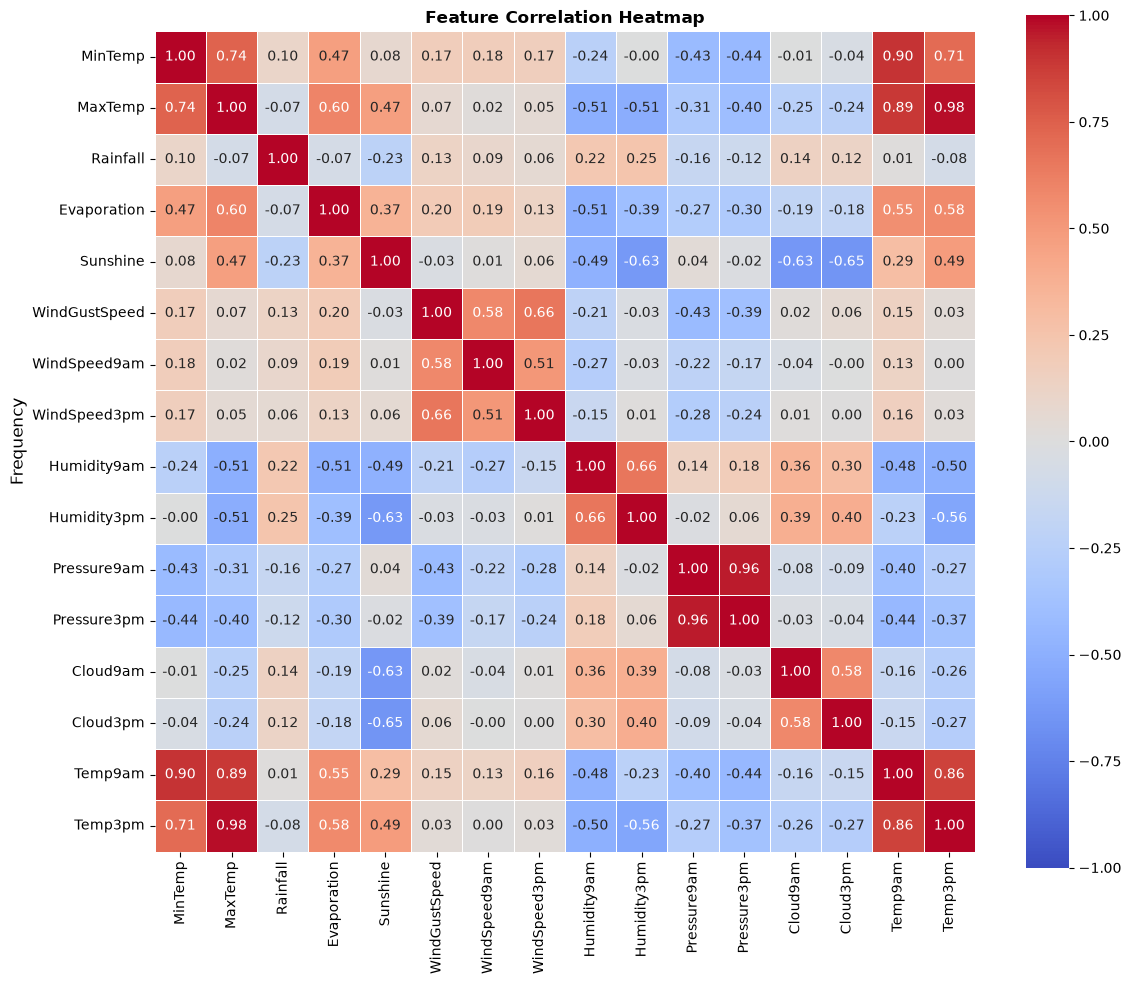

In [133]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)
set_labels("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Numerical vs Target

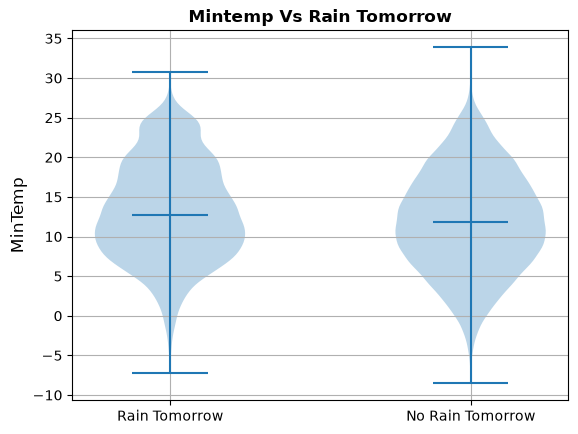

In [73]:
violinplot('MinTemp')
plt.yticks(range(-10,40,5))
plt.show()

##### Observations

**Rain Tomorrow**
- The median temperature is approximately **13°C**.
- Values range from **0°C to 27°C**.
- Most observations fall between **5°C and 25°C**.
- The highest concentration of observations is between **10°C and 15°C**.

**No Rain Tomorrow**
- The median temperature is approximately **12°C**.
- Values range from **−1°C to 26°C**.
- Most observations fall between **0°C and 25°C**.
- The highest concentration of observations is between **10°C and 15°C**.

**Overall Comparison**
- Both groups exhibit very similar distributions, with comparable medians and peak densities.
- The primary difference is that the **No Rain Tomorrow** group includes slightly lower minimum values.
- Based on the violin plots, this feature alone does not appear to strongly distinguish between rainy and non-rainy days.

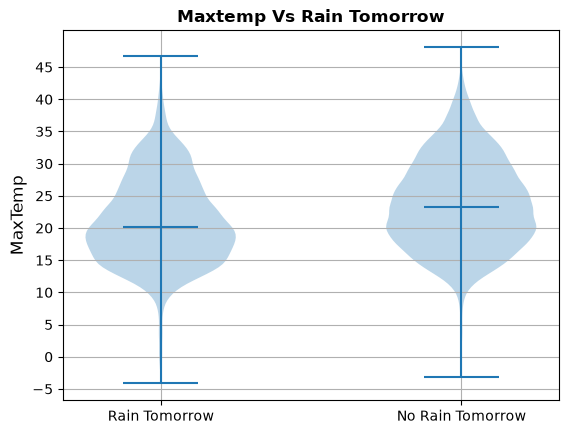

In [74]:
violinplot('MaxTemp')
plt.yticks(range(-5, 50, 5))
plt.show()

#### Observations

**Rain Tomorrow**
- The median temperature is **20°C**.
- Values range from **10°C to 36°C**.
- Most observations fall between **15°C and 25°C**.

**No Rain Tomorrow**
- The median temperature is **24°C**.
- Values range from **10°C to 42°C**.
- Most observations fall between **15°C and 30°C**.

**Overall Comparison**
- The **No Rain Tomorrow** group has a higher median temperature (**24°C**) than the **Rain Tomorrow** group (**20°C**).
- The **No Rain Tomorrow** distribution spans a wider range of values and extends to higher temperatures.
- Although both groups share a similar lower bound, higher temperatures are more common in the **No Rain Tomorrow** group, suggesting that warmer conditions may be associated with a lower likelihood of rainfall on the following day.

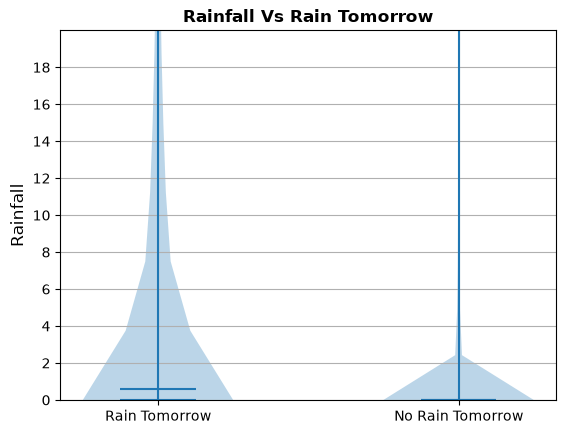

In [75]:
violinplot('Rainfall')
plt.ylim(0, 20)
plt.yticks(range(0, 20, 2))
plt.show()

#### Observations

**Rain Tomorrow**
- The median rainfall is approximately **0.2 mm**.
- Rainfall values range from **0 mm to 18 mm**.
- Most observations fall between **0 mm and 5 mm**.
- The distribution declines sharply after **8 mm**, with very few observations beyond this point.

**No Rain Tomorrow**
- The median rainfall is **0 mm**.
- Most observations fall between **0 mm and 2 mm**.
- Rainfall values greater than **2 mm** are extremely rare.

**Overall Comparison**
- Both groups are heavily concentrated around **low rainfall values**, indicating that little or no rainfall is common in the dataset.
- The **Rain Tomorrow** group exhibits a wider distribution and contains more observations with higher rainfall amounts.
- In contrast, the **No Rain Tomorrow** group is highly concentrated at **0 mm**, suggesting that days with no recorded rainfall are more likely to be followed by another dry day.

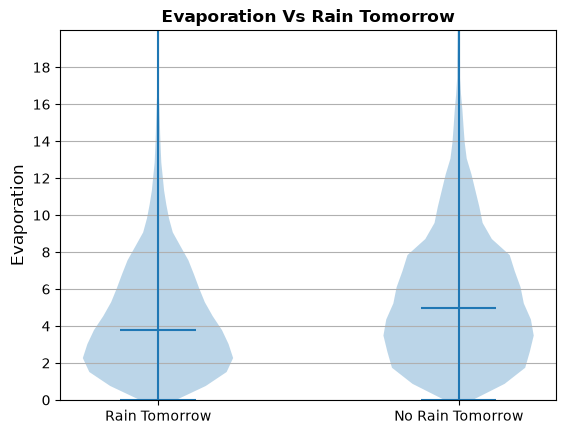

In [76]:
violinplot('Evaporation')
plt.ylim(0, 20)
plt.yticks(range(0, 20, 2))
plt.show()

#### Observations

**Rain Tomorrow**
- The median evaporation is approximately **4 mm**.
- Most observations fall between **0 mm and 8 mm**.
- Evaporation values greater than **11 mm** are uncommon, with the density dropping to nearly zero beyond this point.

**No Rain Tomorrow**
- The median evaporation is approximately **5 mm**.
- Most observations fall between **0 mm and 12 mm**.
- Evaporation values above **14 mm** are relatively rare.

**Overall Comparison**
- The **No Rain Tomorrow** group has a slightly higher median evaporation and a somewhat wider distribution than the **Rain Tomorrow** group.
- Although both distributions are concentrated at lower evaporation values, the **No Rain Tomorrow** group exhibits a modestly greater spread.
- The two distributions overlap considerably, suggesting that **evaporation alone is not a strong discriminator** between rainy and non-rainy days.

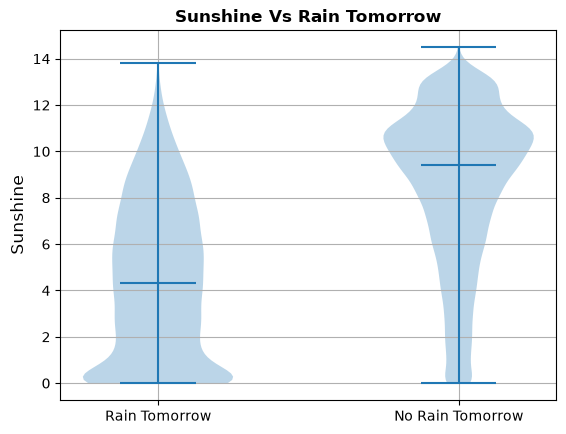

In [77]:
violinplot('Sunshine')
plt.show()

#### Observations

**Rain Tomorrow**
- The median value is approximately **4**.
- Most observations fall between **0 and 10**.
- The distribution is highly concentrated at lower values and tapers gradually, giving it a **rocket-like shape**.

**No Rain Tomorrow**
- The median value is approximately **9.5**.
- Most observations fall between **6 and 14**.
- Values below **6** are relatively uncommon compared with the dominant range.

**Overall Comparison**
- The **No Rain Tomorrow** group has a noticeably higher median than the **Rain Tomorrow** group.
- The **Rain Tomorrow** distribution is concentrated at lower values, whereas the **No Rain Tomorrow** distribution is shifted toward higher values.
- This feature shows a clear difference between the two groups, suggesting that it may be a useful predictor of rainfall on the following day.

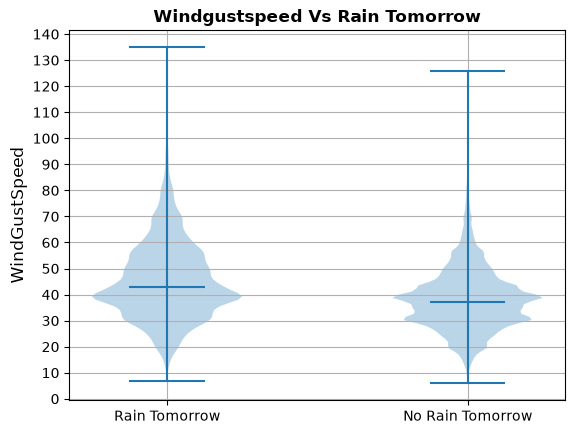

In [122]:
violinplot('WindGustSpeed')
plt.yticks(range(0, 150, 10))
plt.show()

#### Observations

**Rain Tomorrow**
- The median wind speed is approximately **42 km/h**.
- The highest density of observations is around **40 km/h**.
- Most wind speed values fall between **20 km/h and 60 km/h**.

**No Rain Tomorrow**
- The median wind speed is approximately **38 km/h**.
- The highest concentration of observations is around **30–40 km/h**.
- Most wind speed values fall between **25 km/h and 55 km/h**.

**Overall Comparison**
- The two distributions are highly similar and exhibit substantial overlap.
- The **Rain Tomorrow** group has a slightly higher median wind speed than the **No Rain Tomorrow** group.
- Both groups are concentrated within a comparable wind speed range, suggesting that **wind speed alone is unlikely to be a strong predictor** of rainfall on the following day.

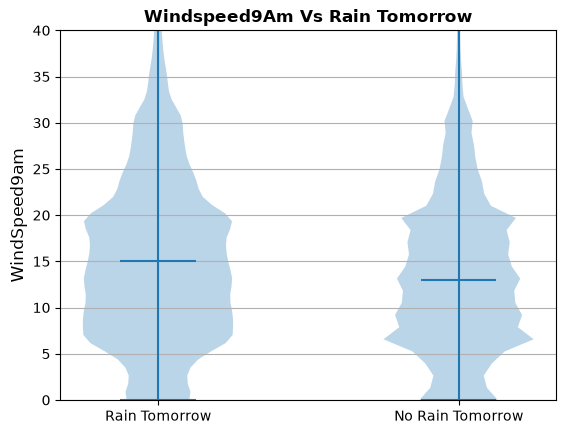

In [124]:
violinplot('WindSpeed9am')
plt.ylim(0, 40)
plt.show()

#### Observations

**Rain Tomorrow**
- The median value is approximately **15**.
- The highest concentration of observations falls between **5 and 20**.
- Values beyond **38** drop significantly, approaching zero.

**No Rain Tomorrow**
- The median value is approximately **13**.
- The highest concentration of observations falls between **5 and 20**.
- Values beyond **35** drop significantly, approaching zero.

**Overall Comparison**
- Both distributions follow a nearly identical pattern with substantial overlap in their primary ranges.
- The **Rain Tomorrow** group shows a slightly higher median than the **No Rain Tomorrow** group (15 vs. 13).
- Both groups share the same core concentration range (5 to 20) and tail off at similar points, suggesting that this variable alone is unlikely to be a strong predictor of rainfall on the following day.

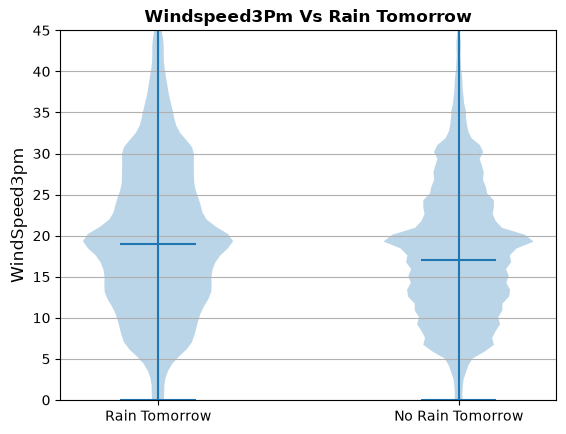

In [80]:
violinplot('WindSpeed3pm')
plt.ylim(0, 45)
plt.show()

#### Observations

**Rain Tomorrow**
- The median wind speed at 3 PM is approximately **19 km/h**.
- The highest concentration of observations (widest peak) is around **18–20 km/h**.
- Most wind speed values fall between **10 km/h and 30 km/h**, with values tapering off significantly above **38 km/h**.

**No Rain Tomorrow**
- The median wind speed at 3 PM is approximately **17 km/h**.
- The highest concentration of observations (widest peak) is also around **18–20 km/h**.
- Most wind speed values fall between **8 km/h and 28 km/h**, with values tapering off significantly above **35 km/h**.

**Overall Comparison**
- The two distributions display a nearly identical shape with substantial overlap across all ranges.
- The **Rain Tomorrow** group shows a slightly higher median wind speed than the **No Rain Tomorrow** group (19 km/h vs. 17 km/h).
- Both groups share similar core ranges and peak densities, indicating that **3 PM wind speed alone is unlikely to be a strong predictor** of rainfall on the following day.

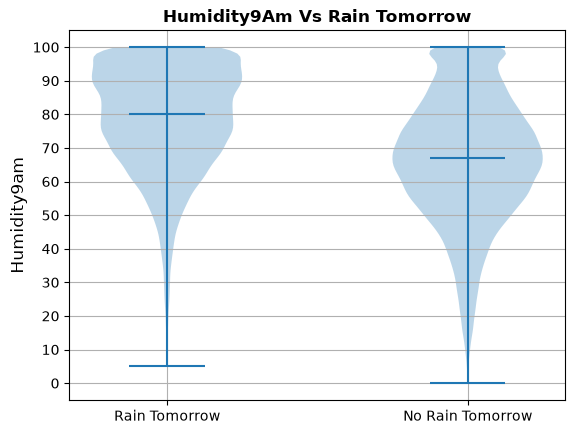

In [81]:
violinplot('Humidity9am')
plt.yticks(range(0, 110, 10))
plt.show()

#### Observations

**Rain Tomorrow**
- The median humidity at 9 AM is approximately **80%**.
- The highest concentration of observations (widest peak) is concentrated between **80% and 95%**.
- Most humidity values fall above **60%**, with lower values tapering off sharply down to a minimum near **5%**.

**No Rain Tomorrow**
- The median humidity at 9 AM is approximately **67%**.
- The highest concentration of observations (widest peak) is centered between **60% and 75%**.
- Most humidity values fall between **50% and 80%**, tapering off towards zero at the lower extreme.

**Overall Comparison**
- The **Rain Tomorrow** group shows a noticeably higher median humidity than the **No Rain Tomorrow** group (80% vs. 67%).
- The distribution for days that rain tomorrow is strongly skewed toward high humidity values (above 70%), whereas days without rain have a lower, more balanced concentration range.
- The clear upward shift in humidity levels when rain occurs suggests that **higher 9 AM humidity is a meaningful predictor** of rainfall on the following day.

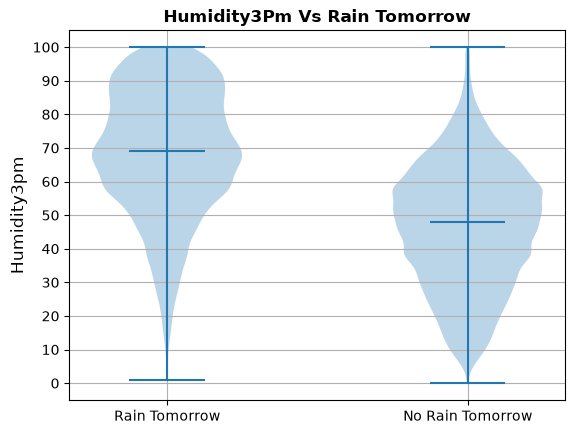

In [82]:
violinplot('Humidity3pm')
plt.yticks(range(0, 110, 10))
plt.show()

#### Observations

**Rain Tomorrow**
- The median humidity at 3 PM is approximately **69%**.
- The highest concentration of observations (widest peak) is centered between **60% and 80%**.
- Most humidity values fall above **50%**, with very few observations dropping below **30%**.

**No Rain Tomorrow**
- The median humidity at 3 PM is approximately **48%**.
- The highest concentration of observations (widest peak) is centered between **45% and 60%**.
- Most humidity values fall between **30% and 65%**, tapering off towards zero at the lower extreme and above 80% at the upper extreme.

**Overall Comparison**
- There is a clear separation between the two distributions, with the **Rain Tomorrow** group shifted significantly toward higher humidity levels.
- The median 3 PM humidity is notably higher when it rains the next day compared to when it does not (**69% vs. 48%**).
- The substantial difference in distribution shapes and central tendencies suggests that **3 PM humidity is a strong predictor** of rainfall on the following day.

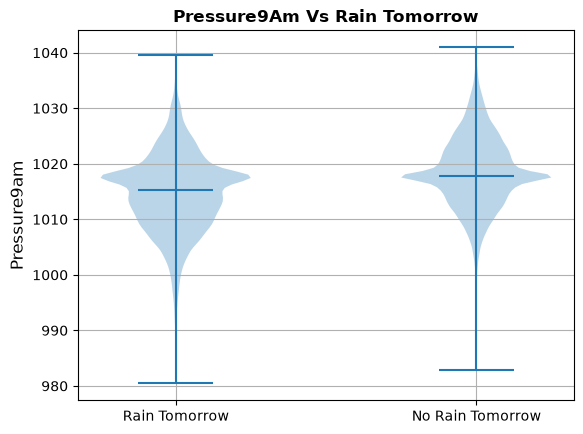

In [83]:
violinplot('Pressure9am')
plt.show()

#### Observations

**Rain Tomorrow**
- The median atmospheric pressure at 9 AM is approximately **1015.5 hPa**.
- The highest concentration of observations (widest peak) is centered around **1017–1018 hPa**.
- Most pressure values fall between **1008 hPa and 1022 hPa**, with lower values extending down toward **980 hPa**.

**No Rain Tomorrow**
- The median atmospheric pressure at 9 AM is approximately **1018 hPa**.
- The highest concentration of observations (widest peak) is also centered around **1017–1018 hPa**.
- Most pressure values fall between **1012 hPa and 1025 hPa**, with values extending down to around **983 hPa**.

**Overall Comparison**
- Both distributions share a very similar peak shape around 1018 hPa, but the **Rain Tomorrow** group shows a slight downward shift.
- The **Rain Tomorrow** group has a slightly lower median pressure than the **No Rain Tomorrow** group (1015.5 hPa vs. 1018 hPa) and a slightly heavier lower tail.
- While lower pressure is mildly associated with rain, the substantial overlap suggests that **9 AM pressure alone is a weak-to-moderate predictor** of rainfall on the following day.

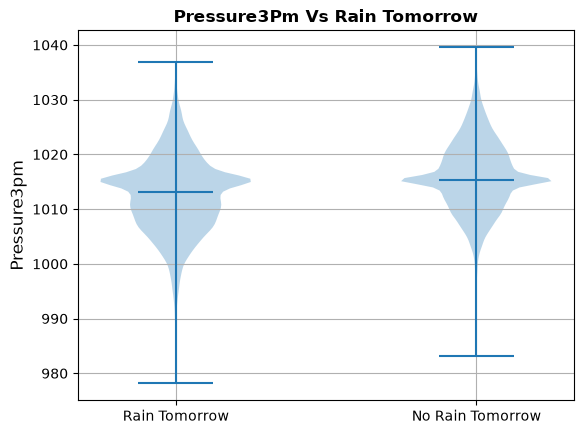

In [84]:
violinplot('Pressure3pm')
plt.show()

#### Observations

**Rain Tomorrow**
- The median atmospheric pressure at 3 PM is approximately **1013 hPa**.
- The highest concentration of observations (widest peak) is centered around **1015 hPa**.
- Most pressure values fall between **1005 hPa and 1018 hPa**, with lower values extending down toward **978 hPa**.

**No Rain Tomorrow**
- The median atmospheric pressure at 3 PM is approximately **1015.5 hPa**.
- The highest concentration of observations (widest peak) is also centered around **1015 hPa**.
- Most pressure values fall between **1010 hPa and 1022 hPa**, with values extending down to around **983 hPa**.

**Overall Comparison**
- Both distributions display a primary concentration peak around 1015 hPa, but the overall body of the **Rain Tomorrow** distribution is shifted lower.
- The **Rain Tomorrow** group shows a slightly lower median pressure than the **No Rain Tomorrow** group (1013 hPa vs. 1015.5 hPa).
- Although lower pressure is moderately associated with rain, the significant overlap between the two groups indicates that **3 PM pressure alone is a weak-to-moderate predictor** of rainfall on the following day.

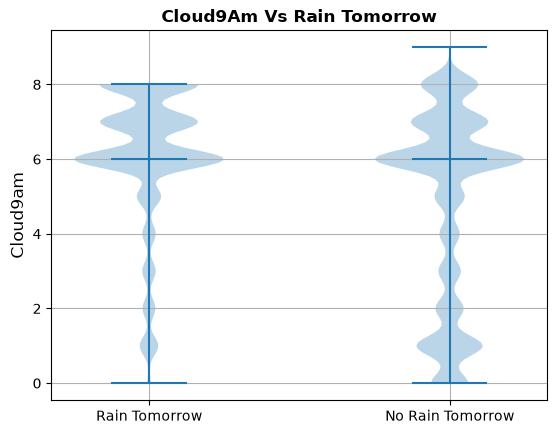

In [85]:
violinplot('Cloud9am')
plt.show()

#### Observations

**Rain Tomorrow**
- The median cloud cover at 9 AM is **6 oktas**.
- The highest concentration of observations (widest peak) is centered around **6 to 7 oktas**.
- Most values are heavily concentrated in the higher range (**5 to 8 oktas**), with very few observations below 4 oktas.

**No Rain Tomorrow**
- The median cloud cover at 9 AM is **6 oktas**.
- The highest concentration of observations (widest peak) is centered around **6 oktas**.
- While higher cloud cover is still common, there is a noticeably broader distribution across lower values (**0 to 5 oktas**), including a minor peak around **1 okta**.

**Overall Comparison**
- Both groups share the same median value (**6 oktas**) and a primary concentration peak at 6 oktas.
- The **Rain Tomorrow** group is distinctly skewed toward overcast/high cloud cover conditions (5–8 oktas), whereas the **No Rain Tomorrow** group exhibits a wider spread that includes clear-sky days (0–2 oktas).
- The absence of low cloud cover on rain days suggests that **low 9 AM cloud cover indicates a low likelihood of rain tomorrow**, making high cloud cover a helpful, though non-exclusive, supporting predictor.

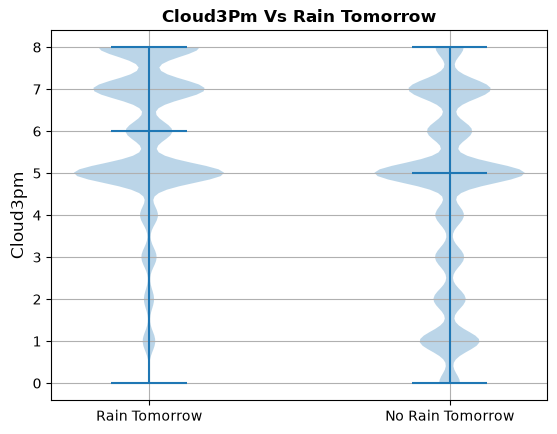

In [86]:
violinplot('Cloud3pm')
plt.show()

#### Observations

**Rain Tomorrow**
- The median cloud cover at 3 PM is **6 oktas**.
- The highest concentration of observations (widest peak) is centered around **5 oktas**, with significant peaks also at **7 oktas**.
- Most values fall between **5 and 7 oktas**, with very few observations below 4 oktas.

**No Rain Tomorrow**
- The median cloud cover at 3 PM is **5 oktas**.
- The highest concentration of observations (widest peak) is centered around **5 oktas**.
- The distribution is broader across lower cloud cover values (**1 to 4 oktas**), with a noticeable secondary peak around **1 okta**.

**Overall Comparison**
- The **Rain Tomorrow** group has a slightly higher median cloud cover than the **No Rain Tomorrow** group (**6 oktas vs. 5 oktas**).
- Days followed by rain are heavily concentrated in high cloudiness ranges (5–8 oktas), whereas days without rain show a substantially larger proportion of clearer sky observations (0–3 oktas).
- The shift toward higher cloud coverage at 3 PM when rain occurs indicates that **3 PM cloud cover is a strong supporting predictor** of rainfall on the following day.

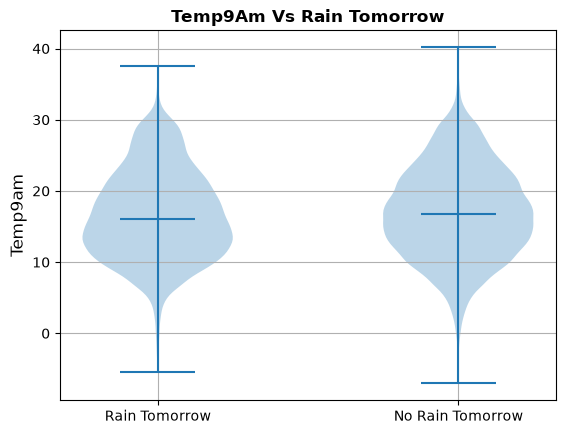

In [87]:
violinplot('Temp9am')
plt.show()

#### Observations

**Rain Tomorrow**
- The median temperature at 9 AM is approximately **16°C**.
- The highest concentration of observations (widest peak) is centered around **13°C to 18°C**.
- Most temperature values fall between **10°C and 22°C**, tapering off below **5°C** and above **32°C**.

**No Rain Tomorrow**
- The median temperature at 9 AM is approximately **17°C**.
- The highest concentration of observations (widest peak) is centered around **14°C to 19°C**.
- Most temperature values fall between **10°C and 24°C**, tapering off below **4°C** and above **35°C**.

**Overall Comparison**
- The two distributions exhibit near-identical shapes and significant overlap throughout their ranges.
- The **No Rain Tomorrow** group has a marginally higher median than the **Rain Tomorrow** group (**17°C vs. 16°C**) and extends slightly higher into extreme warm temperatures.
- The high degree of overlap and matching core density ranges suggest that **9 AM temperature alone is unlikely to be a strong predictor** of rainfall on the following day.

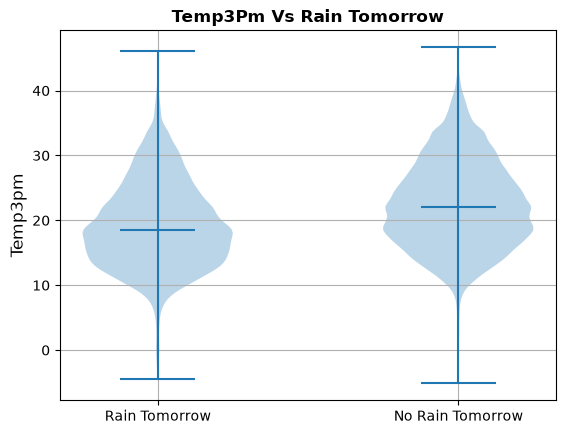

In [88]:
violinplot('Temp3pm')
plt.show()

#### Observations

**Rain Tomorrow**
- The median temperature at 3 PM is approximately **18.5°C**.
- The highest concentration of observations (widest peak) is centered around **16°C to 20°C**.
- Most temperature values fall between **12°C and 25°C**, with values dropping off significantly above **35°C**.

**No Rain Tomorrow**
- The median temperature at 3 PM is approximately **22°C**.
- The highest concentration of observations (widest peak) is centered around **18°C to 24°C**.
- Most temperature values fall between **15°C and 30°C**, extending higher toward **40°C**.

**Overall Comparison**
- The **No Rain Tomorrow** distribution is visibly shifted higher than the **Rain Tomorrow** group, showing a clear difference in median values (**22°C vs. 18.5°C**).
- Days that are not followed by rain tend to reach warmer afternoon temperatures, whereas days followed by rain remain cooler at 3 PM.
- The noticeable shift suggests that lower 3 PM temperatures are associated with rain the next day, making **3 PM temperature a moderately useful predictor**.

### Categorical Vs Target

In [ ]:
def crosstab_barchart(categorical_column, bar_kind='bar', figsize=(8, 6)):
    crosstab_result = pd.crosstab(
        index=df[categorical_column], 
        columns=df['RainTomorrow'], 
        normalize='index'
        )
    ax = crosstab_result.plot(
        kind=bar_kind,  # type: ignore
        stacked=True, 
        color=[NO_COLOR, YES_COLOR], 
        figsize=figsize
        )
    set_labels(f"{categorical_column} vs RainTomorrow (Proportion)", xlabel=categorical_column, ylabel="Proportion")
    plt.xticks(rotation=45)
    plt.legend(title="Rain Tomorrow", labels=['No', 'Yes'])
    plt.tight_layout()
    plt.show()

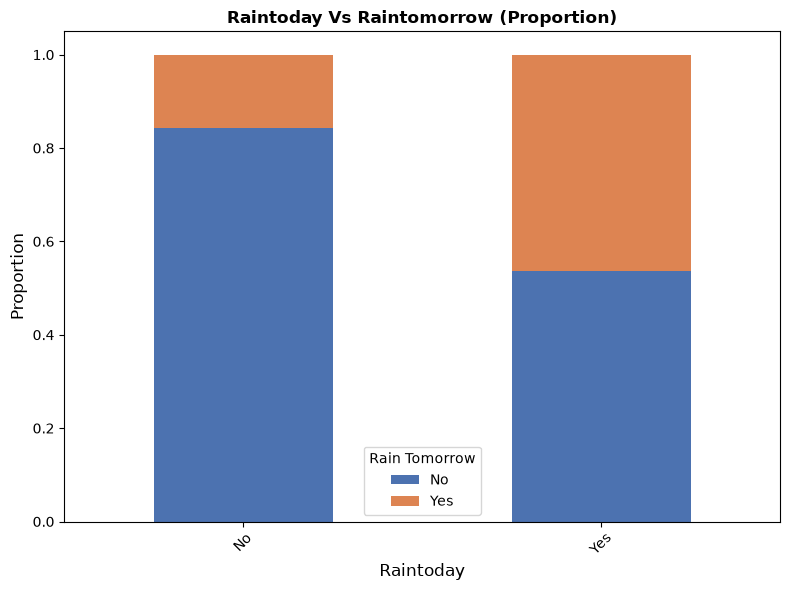

In [106]:
crosstab_barchart('RainToday')

#### Observations

**RainToday = No**
- **No Rain Tomorrow**: Approximately **84%** of days with no rain today remain dry tomorrow.
- **Rain Tomorrow**: Only about **16%** of days with no rain today result in rain tomorrow.

**RainToday = Yes**
- **No Rain Tomorrow**: Approximately **54%** of rainy days today clear up tomorrow.
- **Rain Tomorrow**: Roughly **46%** of rainy days today lead to rain again tomorrow.

**Overall Comparison**
- If it **does not rain today**, there is a very high probability (~84%) that it will stay dry tomorrow.
- If it **does rain today**, the probability of rain tomorrow almost triples (jumping from ~16% to ~46%).
- This substantial increase in the likelihood of next-day rain makes **RainToday a strong categorical predictor** for predicting **RainTomorrow**.

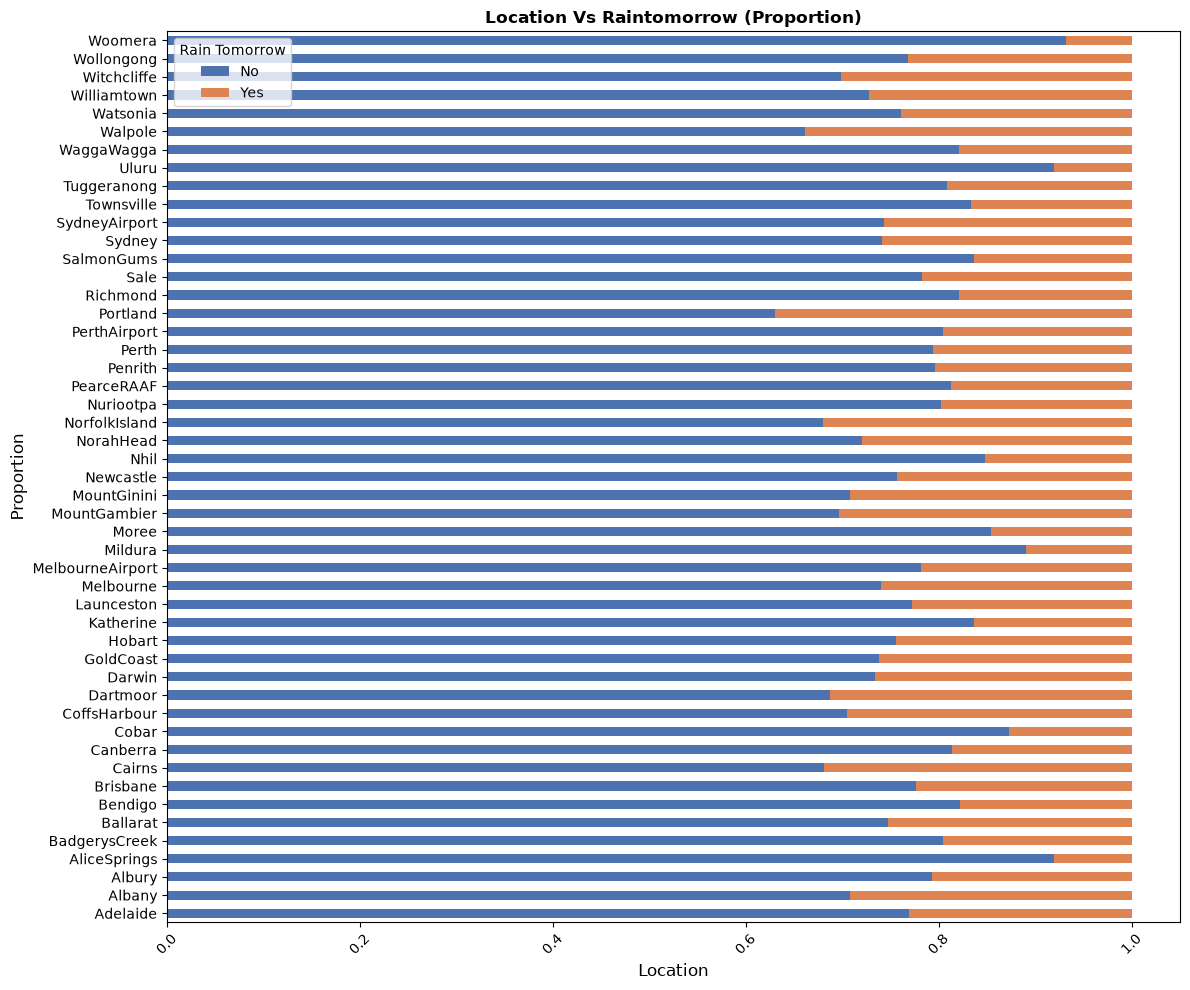

In [113]:
crosstab_barchart('Location', 'barh', figsize=(12, 10))

#### Observations

**Locations with Lowest Rain Likelihood**
- Locations such as **Woomera**, **Uluru**, **Mildura**, **Alice Springs**, and **Cobar** show the lowest proportion of rainy days tomorrow.
- In these arid/dry regions, the proportion of **No Rain Tomorrow** exceeds **85% to 90%** (with Woomera and Uluru reaching ~92–95%).

**Locations with Highest Rain Likelihood**
- Locations such as **Portland**, **Walpole**, **Cairns**, **Dartmoor**, **NorfolkIsland**, and **MountGambier** show the highest proportion of rainy days tomorrow.
- In these wetter coastal or elevated regions, the proportion of **Rain Tomorrow** approaches or exceeds **35% to 37%** (with Portland reaching around 37%).

**Overall Comparison**
- Rain likelihood varies significantly across different geographic locations, ranging from under **10%** in desert regions to nearly **40%** in wet coastal areas.
- Most locations cluster around a baseline of **15% to 25%** probability of rain on the following day.
- The strong geographic variation demonstrates that **Location is a valuable categorical feature** for predicting **RainTomorrow**.

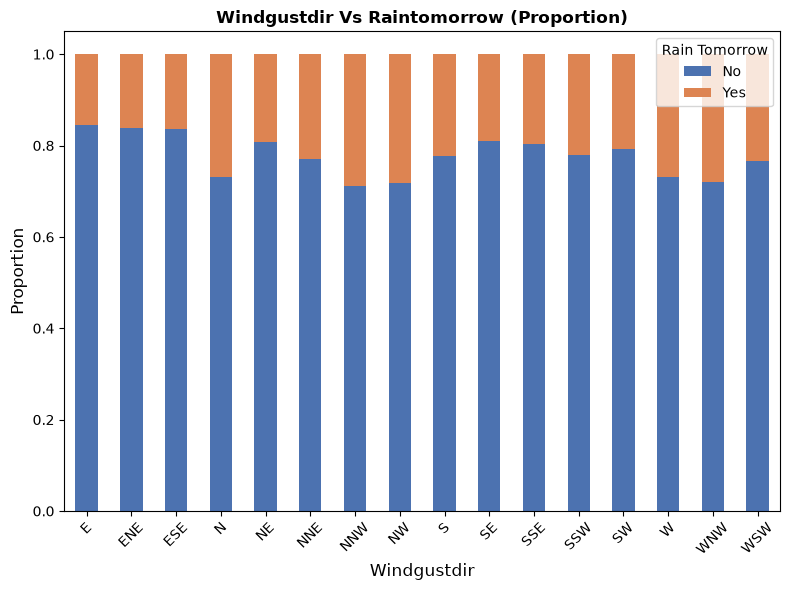

In [119]:
crosstab_barchart('WindGustDir')

#### Observations

**Directions with Lowest Rain Likelihood**
- Wind gust directions from the East, such as **E**, **ENE**, and **ESE**, show the highest proportion of dry days tomorrow.
- For these easterly directions, the proportion of **No Rain Tomorrow** reaches approximately **84% to 85%** (meaning only ~15–16% chance of rain).

**Directions with Highest Rain Likelihood**
- Wind gust directions from the Northwest and West, including **NNW**, **NW**, **W**, and **WNW**, show the highest proportion of rainy days tomorrow.
- For these northwesterly/westerly directions, the proportion of **Rain Tomorrow** increases to approximately **27% to 29%**.

**Overall Comparison**
- The likelihood of rain varies noticeably depending on wind gust direction, ranging from ~15% for easterly winds up to nearly ~29% for westerly/northwesterly winds.
- Southerly and easterly directions generally correlate with drier conditions, whereas westerly and northerly directions correlate with higher rain probability.
- This distinct directional variation suggests that **WindGustDir provides useful predictive value** for forecasting **RainTomorrow**.

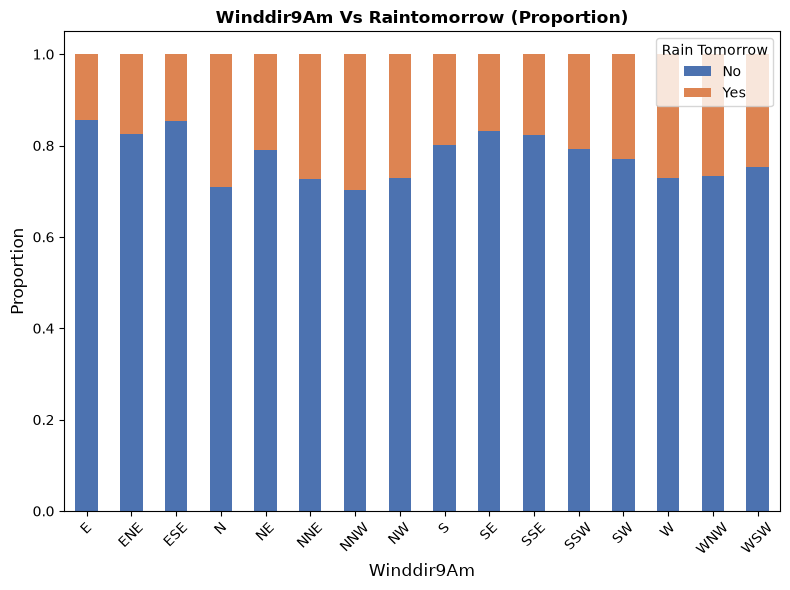

In [ ]:
crosstab_barchart('WindDir9am')


#### Observations

**Directions with Lowest Rain Likelihood**
- 9 AM wind directions from the East and Southeast, such as **E**, **ESE**, **SE**, and **ENE**, show the highest proportion of dry days tomorrow.
- For these easterly directions, the proportion of **No Rain Tomorrow** reaches between **83% and 86%** (meaning only a ~14–17% chance of rain).

**Directions with Highest Rain Likelihood**
- 9 AM wind directions from the North and Northwest, particularly **NNW**, **N**, **NW**, and **NNE**, show the highest proportion of rainy days tomorrow.
- For these directions, the proportion of **Rain Tomorrow** increases to approximately **27% to 30%** (with NNW approaching ~30%).

**Overall Comparison**
- The likelihood of next-day rain varies visibly with morning wind direction, ranging from ~14% for easterly winds up to nearly ~30% for north/northwesterly winds.
- Easterly and southeasterly morning winds consistently favor dry weather, whereas northerly and northwesterly morning winds correlate with higher rainfall probability.
- This clear directional pattern confirms that **WindDir9Am provides useful supporting information** for forecasting **RainTomorrow**.

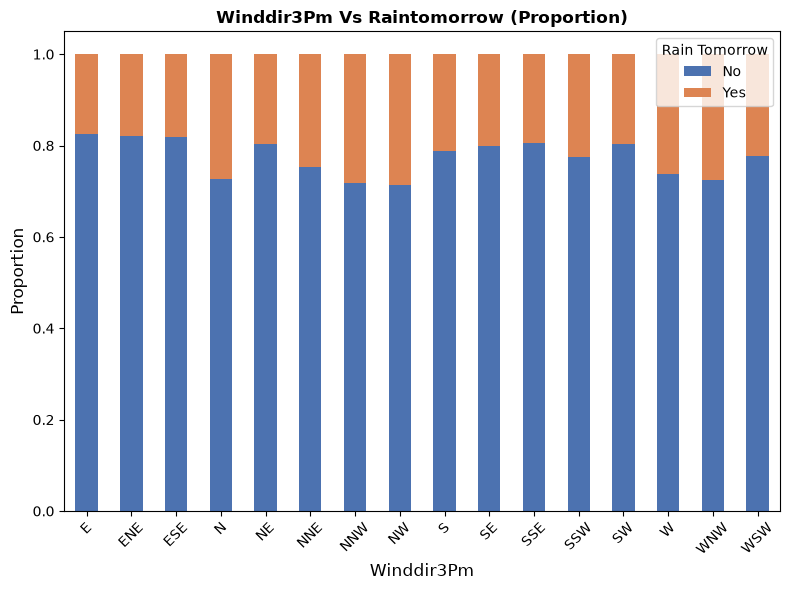

In [121]:
crosstab_barchart('WindDir3pm')

#### Observations

**Directions with Lowest Rain Likelihood**
- 3 PM wind directions from the East and Southeast, such as **E**, **ENE**, and **ESE**, show the highest proportion of dry days tomorrow.
- For these easterly directions, the proportion of **No Rain Tomorrow** reaches approximately **82% to 83%** (meaning only a ~17–18% chance of rain).

**Directions with Highest Rain Likelihood**
- 3 PM wind directions from the Northwest and West, particularly **NW**, **NNW**, **N**, **W**, and **WNW**, show the highest proportion of rainy days tomorrow.
- For these northwesterly and westerly directions, the proportion of **Rain Tomorrow** increases to approximately **27% to 29%**.

**Overall Comparison**
- The likelihood of next-day rain varies visibly based on afternoon wind direction, ranging from ~17% for easterly winds up to nearly ~29% for northwesterly winds.
- Easterly afternoon winds consistently align with clear/dry weather, whereas northwesterly and westerly winds correlate with higher rainfall probability.
- This consistent directional pattern demonstrates that **WindDir3Pm provides useful supporting information** for forecasting **RainTomorrow**.